In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv('heart.csv')


In [36]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [38]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [39]:
df.shape

(918, 12)

In [40]:
df.duplicated().sum()


np.int64(0)

In [41]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='HeartDisease'>

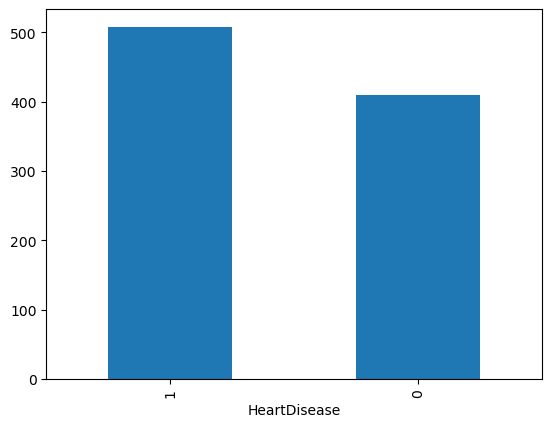

In [42]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [43]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

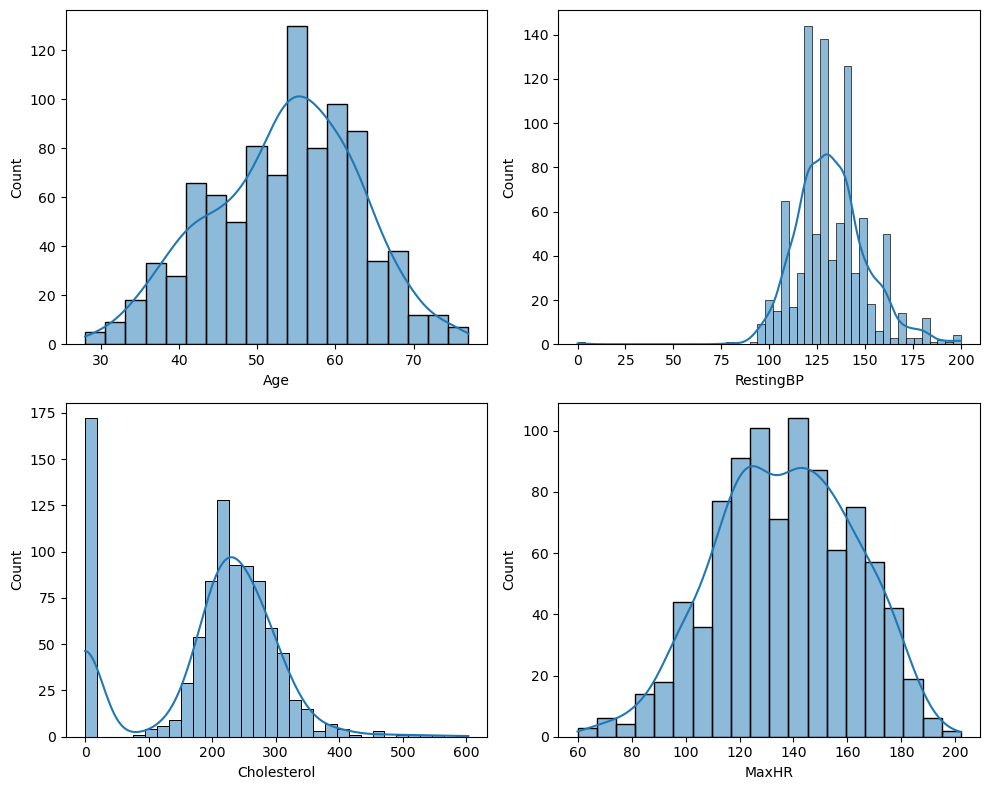

In [44]:

def plotting(x,n):
    plt.subplot(2,2,n)
    sns.histplot(df[x],kde=True)
    
plt.figure(figsize=(10,8))
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()


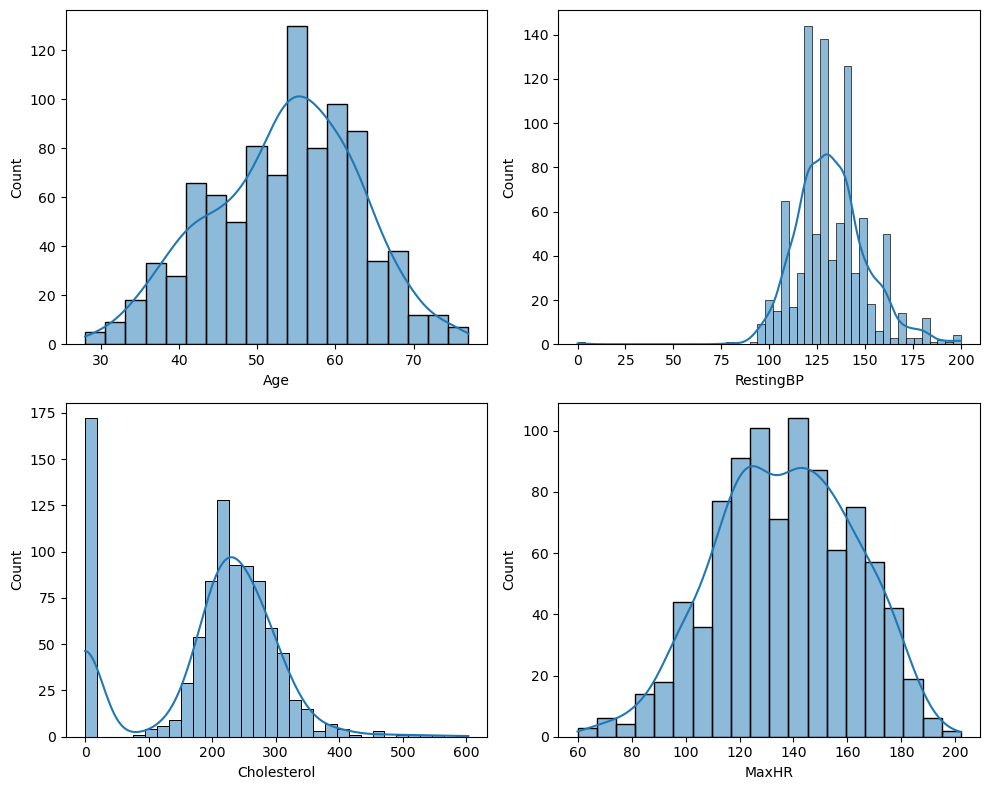

In [45]:
cols = ['Age','RestingBP','Cholesterol','MaxHR']

plt.figure(figsize=(10,8))

for i, col in enumerate(cols,1):
    plotting(col,i)

plt.tight_layout()
plt.show()

In [46]:
ch_mean=  df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [47]:
ch_mean=ch_mean.round(2)
ch_mean

np.float64(244.64)

In [48]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)
df[df['Cholesterol']!=0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236.0,0,LVH,174,N,0.0,Flat,1


<Axes: xlabel='Cholesterol', ylabel='Count'>

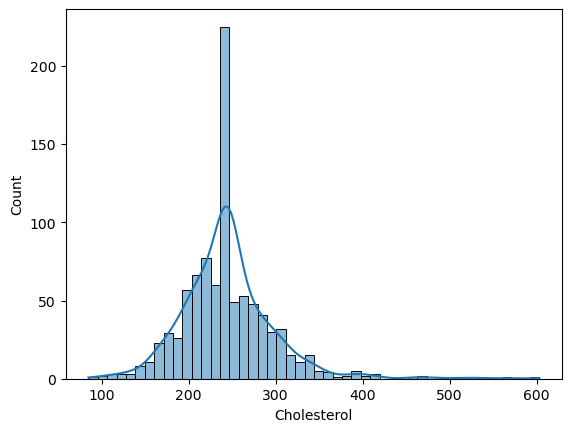

In [49]:
sns.histplot(df['Cholesterol'],kde=True)

In [50]:
rbp_mean=df.loc[df['RestingBP']!=0,'RestingBP'].mean().round(2)

<Axes: xlabel='RestingBP', ylabel='Count'>

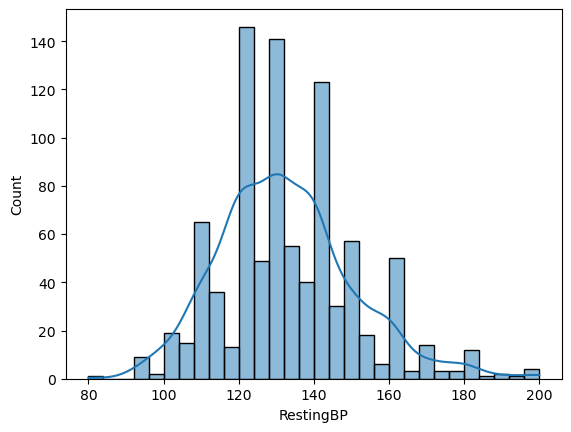

In [51]:
df['RestingBP']=df['RestingBP'].replace(0,rbp_mean)
sns.histplot(df['RestingBP'],kde=True)

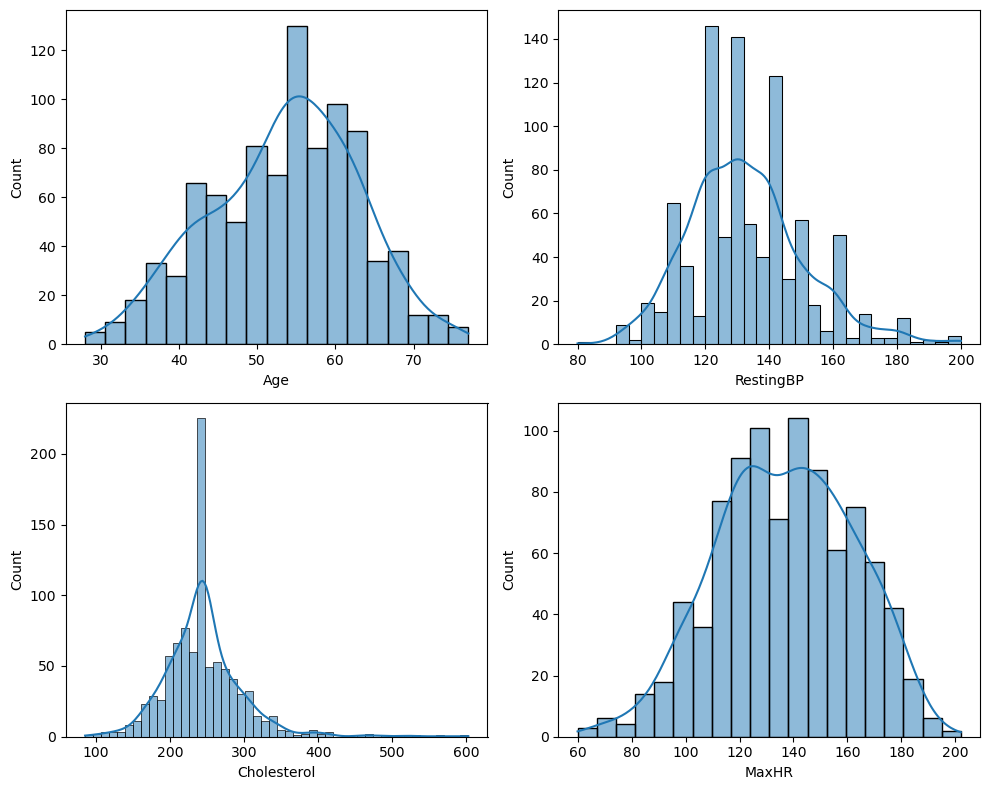

In [52]:
cols = ['Age','RestingBP','Cholesterol','MaxHR']
plt.figure(figsize=(10,8))
for i,col in enumerate(cols,1):
    plotting(col,i)
plt.tight_layout()


<Axes: xlabel='ChestPainType', ylabel='count'>

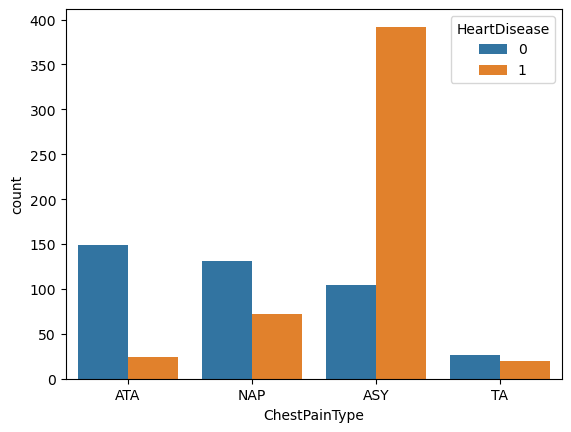

In [53]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='Sex', ylabel='count'>

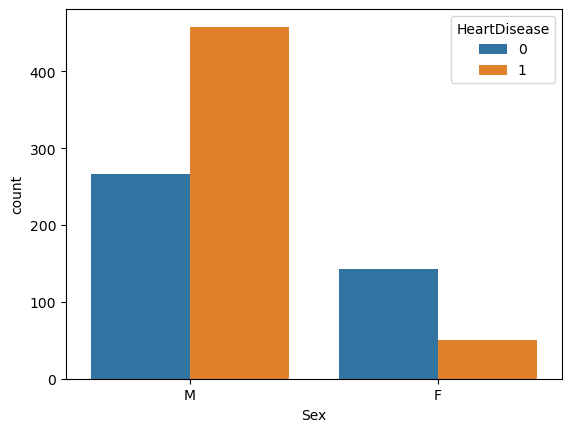

In [54]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: >

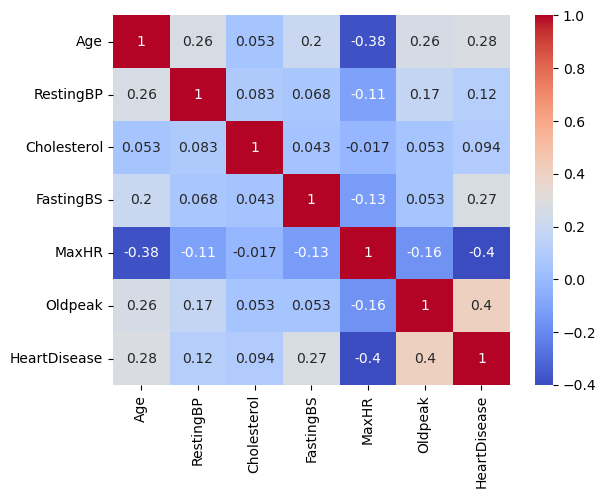

In [55]:
sns.heatmap(df.corr(numeric_only=True),cmap='coolwarm',annot=True)

In [56]:
df_encode=pd.get_dummies(df,drop_first=True)

In [57]:
df_encode=df_encode.astype(int)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn. linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn. tree import DecisionTreeClassifier
from sklearn. svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [59]:
X=df_encode.drop(columns='HeartDisease')
y=df_encode['HeartDisease']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)


In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [61]:
models = {
"Logistic Regression" : LogisticRegression(),
"KNN" : KNeighborsClassifier(n_neighbors=7),
"Naive Byeas": GaussianNB(),
"Decision tree" : DecisionTreeClassifier(),
"SVM" : SVC(probability=True)
}

In [62]:
result=[]


In [63]:
for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    result.append({
        'model':name,
        'Accuracy':round(acc,4),
        'f1 score':round(f1,4)
    })

In [64]:
result

[{'model': 'Logistic Regression', 'Accuracy': 0.8696, 'f1 score': 0.8846},
 {'model': 'KNN', 'Accuracy': 0.8587, 'f1 score': 0.8738},
 {'model': 'Naive Byeas', 'Accuracy': 0.8478, 'f1 score': 0.8614},
 {'model': 'Decision tree', 'Accuracy': 0.7826, 'f1 score': 0.798},
 {'model': 'SVM', 'Accuracy': 0.8478, 'f1 score': 0.8667}]

In [65]:
import joblib
joblib.dump(models['Logistic Regression'],'LG.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(X.columns.tolist(),'col.pkl')

['col.pkl']